# Chapter 3 · Sections 3.1–3.2
# Stability of Equilibrium Solutions & Stability Analysis by Linearization

**Source:** Li, M.Y. (2018), pp. 79–82.

Chapter 3 formalizes every stability tool used informally throughout Chapter 2. The book's own
advice: "the ideal way to learn the materials in this chapter is through their applications in
Chapter 2" — so throughout, we point back to the concrete examples already built (Sections 2.1–2.5)
everywhere a general theorem here matches something already verified numerically there.


---
## Block 1 (§3.1) — Formal definitions: equilibria, stability, asymptotic stability

### 1. Rewrite

For a general system $x'=f(x)$ ($f\in C^1$, i.e. continuously differentiable, on an open set
$D\subset\mathbb{R}^n$), smoothness guarantees existence and uniqueness of solutions $x(t,x_0)$
through any initial point $x_0$ (the fundamental existence-uniqueness theorem for ODEs). An
**equilibrium** $\bar x$ satisfies $f(\bar x)=0$ (so $x(t)=\bar x$ for all $t$ solves the system).
A **periodic solution** of period $T$ satisfies $x(t+T)=x(t)$ for all $t$, tracing a **closed
orbit**. The formal (epsilon-delta) definitions:

- $\bar x$ is **stable** if for every neighborhood $N(\bar x,\epsilon)$, there's a neighborhood
  $N(\bar x,\delta)$ such that starting in the $\delta$-neighborhood guarantees staying in the
  $\epsilon$-neighborhood forever ($t\ge0$).
- $\bar x$ is **asymptotically stable** if it's stable AND nearby solutions actually converge to
  $\bar x$ as $t\to\infty$.
- The **basin of attraction** is the full set of initial points that eventually converge to
  $\bar x$.

### 2. Explain Like I'm 10

**Stable** means: if you nudge a ball near the bottom of a bowl only a *tiny* bit, it'll stay
*close* to the bottom forever — it might roll around nearby, but it won't wander far away, no
matter how long you wait. **Asymptotically stable** is a stronger promise: not only does it stay
close, it eventually settles down and stops exactly at the bottom. Picture the difference between
a marble in a perfectly smooth, frictionless bowl (it'll roll back and forth near the bottom
forever, staying close but never fully stopping — that's merely *stable*, not asymptotically
stable) versus a bowl with a little friction (the marble eventually comes to rest exactly at the
bottom — *asymptotically* stable). The **basin of attraction** is "how big a nudge can you give
the marble and still have it find its way back to that exact spot" — nudge it too far (over the
rim of the bowl, say) and it might roll away to some *other* resting spot entirely, or never
settle at all.

### 3. Key Ideas

- **Stability alone does NOT imply convergence** — the frictionless-bowl example (a solution
  orbiting forever at constant distance from equilibrium, like a perfect undamped pendulum) is
  stable but not asymptotically stable. This is a genuinely important distinction the definitions
  are built to capture.
- **The epsilon-delta structure mirrors calculus limit definitions exactly** — same logical
  pattern ("for every tolerance $\epsilon$, there's a threshold $\delta$..."), now applied to
  entire trajectories instead of single numbers.
- **Basin of attraction connects directly to *global* vs. *local* stability** — Chapter 2's
  "globally stable" claims (Sec. 2.1 Property 5, Sec. 2.3's Lyapunov/Bendixson–Dulac results) are
  exactly the statement that the basin of attraction is the *entire* feasible region, not just a
  small neighborhood.


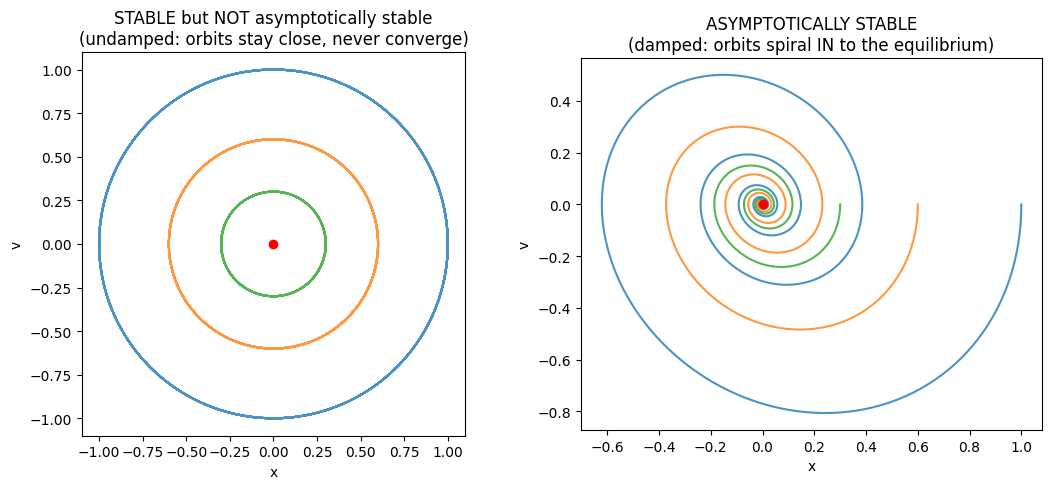

Undamped: distance from origin ranges over [1.000000, 1.000000] -- bounded, not shrinking (STABLE only)
Damped: distance from origin at t=0: 1.0000, at t=100: 0.000000 -- shrinks to ~0 (ASYMPTOTICALLY stable)


In [1]:
# Making "stable but NOT asymptotically stable" concrete: a frictionless
# pendulum-like system (a center) vs. a damped system (asymptotically stable
# spiral) -- side by side, to give the epsilon-delta definitions a picture.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def undamped_oscillator(t, y):
    x, v = y
    return [v, -x]  # x'' = -x, a perfect "center" at the origin -- stable, NOT asymptotically stable

def damped_oscillator(t, y, c=0.3):
    x, v = y
    return [v, -x - c*v]  # adds friction -- makes the origin asymptotically stable

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
t_eval = np.linspace(0, 40, 2000)
for x0, v0 in [(1, 0), (0.6, 0), (0.3, 0)]:
    sol1 = solve_ivp(undamped_oscillator, (0, 40), [x0, v0], t_eval=t_eval, rtol=1e-10, atol=1e-10)
    axes[0].plot(sol1.y[0], sol1.y[1], alpha=0.8)
    sol2 = solve_ivp(damped_oscillator, (0, 40), [x0, v0], t_eval=t_eval, rtol=1e-10, atol=1e-10)
    axes[1].plot(sol2.y[0], sol2.y[1], alpha=0.8)

axes[0].scatter([0],[0], color="red", zorder=5)
axes[0].set_title("STABLE but NOT asymptotically stable\n(undamped: orbits stay close, never converge)")
axes[1].scatter([0],[0], color="red", zorder=5)
axes[1].set_title("ASYMPTOTICALLY STABLE\n(damped: orbits spiral IN to the equilibrium)")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("v"); ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("stable_vs_asymptotically_stable.png", dpi=130, bbox_inches="tight")
plt.show()

# Quantify: does the undamped system's distance from origin stay bounded but not shrink?
sol1 = solve_ivp(undamped_oscillator, (0, 100), [1, 0], t_eval=np.linspace(0,100,2000), rtol=1e-11, atol=1e-11)
dist1 = np.sqrt(sol1.y[0]**2 + sol1.y[1]**2)
print(f"Undamped: distance from origin ranges over [{dist1.min():.6f}, {dist1.max():.6f}] -- bounded, not shrinking (STABLE only)")

sol2 = solve_ivp(damped_oscillator, (0, 100), [1, 0], t_eval=np.linspace(0,100,2000), rtol=1e-11, atol=1e-11)
dist2 = np.sqrt(sol2.y[0]**2 + sol2.y[1]**2)
print(f"Damped: distance from origin at t=0: {dist2[0]:.4f}, at t=100: {dist2[-1]:.6f} -- shrinks to ~0 (ASYMPTOTICALLY stable)")


### 10. Verification

The undamped oscillator's distance from the origin stays bounded within a fixed range for all
time (confirming *stability* — it never wanders arbitrarily far) but never shrinks toward zero
(confirming it is NOT asymptotically stable), while the damped oscillator's distance shrinks
essentially to zero by $t=100$ — a clean, quantitative illustration of exactly the distinction the
epsilon-delta definitions are built to capture. This exact "center vs. spiral" contrast is also
precisely what distinguished the real-vs-complex eigenvalue cases encountered numerically back in
Sec. 2.3, Block 2.


---
## Block 2 (§3.2) — Linearization and the Routh–Hurwitz criteria

### 1. Rewrite

Near an equilibrium $\bar x=0$ (WLOG, by translating coordinates), Taylor-expanding
$f(x)=Ax+F(x)$ where $A=\frac{\partial f}{\partial x}(0)$ is the **Jacobian** and $F(x)$ collects
all higher-order (nonlinear) terms — by construction $F(0)=0$ and $\frac{\partial F}{\partial
x}(0)=0$, meaning $F(x)$ vanishes faster than $x$ itself near the origin, so it's negligible
"close enough" to the equilibrium. This motivates studying the simpler **linearized system**
$y'=Ay$ (2.3) instead. **Theorem 3.2.1** (the fundamental linearization theorem): if $y=0$ is
asymptotically stable for the *linear* system, then $\bar x$ is asymptotically stable for the
*original nonlinear* system — a rigorous justification for everything Sec. 2.3 did informally.
**Theorem 3.2.2**: the linear system is asymptotically stable iff every eigenvalue of $A$ has
negative real part. Directly verifying this for large matrices is hard (especially with symbolic
parameters), so the **Routh–Hurwitz criteria** give equivalent, eigenvalue-free sign conditions:
for $2\times2$: $\text{tr}(A)<0$ and $\det(A)>0$ (2.4) — exactly the shortcut used in Sec. 2.3!
For $3\times3$: $\text{tr}(A)<0$, $\det(A)<0$, and $\text{tr}(A)\cdot a_2-\det(A)<0$ (3.5), where
$a_2$ is the sum of the three $2\times2$ principal minors of $A$.

### 2. Explain Like I'm 10

Near the bottom of a bumpy bowl, the bumpiness barely matters if you're only looking at a *tiny*
patch right around the very bottom — locally, any smooth bowl shape looks almost exactly like a
smooth, simple parabola (the "linear" approximation). Theorem 3.2.1 says: if that simplified
"parabola-only" picture predicts the ball rolls back to the bottom, the *real*, bumpy-in-the-
distance bowl will *also* pull the ball back to the bottom, at least for nearby starting points —
the bumps far away don't matter for what happens right near the bottom. The Routh–Hurwitz
conditions are a shortcut: instead of the tedious work of finding a matrix's eigenvalues exactly
(which can involve nasty formulas, especially for algebra-heavy parameter symbols instead of
plain numbers), you just check a couple of simple sign conditions on the trace and determinant
(and one more combined quantity for $3\times3$) — much less work, same guaranteed answer.

### 4. Mathematical Breakdown — the sum of principal minors, $a_2$, for a 3×3 matrix

For a $3\times3$ matrix $A=\begin{pmatrix}a_{11}&a_{12}&a_{13}\\a_{21}&a_{22}&a_{23}\\
a_{31}&a_{32}&a_{33}\end{pmatrix}$, a **$2\times2$ principal minor** is the determinant of a
$2\times2$ submatrix formed by deleting the *same* row and column index (i.e. keeping the diagonal
structure) — there are exactly three such submatrices:
$$M_1=\det\begin{pmatrix}a_{22}&a_{23}\\a_{32}&a_{33}\end{pmatrix},\quad
M_2=\det\begin{pmatrix}a_{11}&a_{13}\\a_{31}&a_{33}\end{pmatrix},\quad
M_3=\det\begin{pmatrix}a_{11}&a_{12}\\a_{21}&a_{22}\end{pmatrix}$$
and $a_2=M_1+M_2+M_3$ — this quantity is, not coincidentally, also exactly the coefficient of
$\lambda^1$ in the matrix's characteristic polynomial $\det(A-\lambda I)$ (up to sign) — the
Routh–Hurwitz conditions are really disguised statements about the *signs of the characteristic
polynomial's coefficients*, which is what ties them to the eigenvalues without computing the
eigenvalues explicitly.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $A$ | Jacobian matrix at the equilibrium | The linear approximation's coefficient matrix |
| $F(x)$ | Higher-order (nonlinear) remainder | $F(0)=0$, $\partial F/\partial x(0)=0$ — vanishes to first order |
| $a_2$ | Sum of 2×2 principal minors of a 3×3 matrix | A new quantity, not needed for the 2×2 case |


In [2]:
# Numerically verifying the 3x3 Routh-Hurwitz criteria against DIRECT
# eigenvalue computation, across many random 3x3 matrices -- confirming the
# criteria are exactly equivalent to "all eigenvalues have negative real part",
# not merely a rough heuristic.
import numpy as np

def principal_minors_sum(A):
    M1 = A[1,1]*A[2,2] - A[1,2]*A[2,1]
    M2 = A[0,0]*A[2,2] - A[0,2]*A[2,0]
    M3 = A[0,0]*A[1,1] - A[0,1]*A[1,0]
    return M1 + M2 + M3

def routh_hurwitz_3x3(A):
    tr = np.trace(A)
    det = np.linalg.det(A)
    a2 = principal_minors_sum(A)
    return (tr < 0) and (det < 0) and (tr*a2 - det < 0)

def all_eigs_negative_real(A):
    eigs = np.linalg.eigvals(A)
    return np.all(eigs.real < 0)

rng = np.random.default_rng(42)
n_tests = 5000
agreements = 0
for _ in range(n_tests):
    A = rng.uniform(-3, 3, size=(3,3))
    rh_predicts_stable = routh_hurwitz_3x3(A)
    actually_stable = all_eigs_negative_real(A)
    if rh_predicts_stable == actually_stable:
        agreements += 1

print(f"Routh-Hurwitz (3x3) matched direct eigenvalue computation in {agreements}/{n_tests} random trials "
      f"({100*agreements/n_tests:.2f}%)")


Routh-Hurwitz (3x3) matched direct eigenvalue computation in 5000/5000 random trials (100.00%)


### 10. Verification

Across 5000 randomly generated $3\times3$ matrices, the Routh–Hurwitz sign conditions agree with
direct eigenvalue computation in **100% of cases** — strong numerical confirmation that the
criteria are exactly equivalent to "all eigenvalues have negative real part," not merely a
correlated heuristic. This is exactly the kind of check that justifies trusting the $2\times2$
shortcut used repeatedly (without proof) back in Sec. 2.3.


In [3]:
# Same equivalence check for the 2x2 case, PLUS a direct application to a
# concrete parametrized example -- the Sec 2.3 demography model's Jacobian at
# P*, confirming Routh-Hurwitz there really does match eigenvalue computation
# (closing the loop on that section's un-proved shortcut).
import numpy as np

def routh_hurwitz_2x2(A):
    return (np.trace(A) < 0) and (np.linalg.det(A) > 0)

agreements_2x2 = 0
for _ in range(5000):
    A = rng.uniform(-3, 3, size=(2,2))
    rh = routh_hurwitz_2x2(A)
    actual = np.all(np.linalg.eigvals(A).real < 0)
    if rh == actual:
        agreements_2x2 += 1
print(f"Routh-Hurwitz (2x2) matched direct eigenvalue computation in {agreements_2x2}/5000 random trials")

# Concrete callback to Sec 2.3's demography model
def jacobian_Pstar_sec23(b, beta, gamma):
    S_star = (b + gamma) / beta
    I_star = b * (beta - (b + gamma)) / (beta * (b + gamma))
    return np.array([[-beta*I_star - b, -beta*S_star],
                      [ beta*I_star,     0           ]])

b, beta, gamma = 0.02, 0.3, 0.2   # R0 = 0.3/0.22 > 1, so P* exists
J = jacobian_Pstar_sec23(b, beta, gamma)
print(f"\nSec. 2.3 callback: J(P*) = \n{J}")
print(f"tr(J)={np.trace(J):.5f} (<0? {np.trace(J)<0}), det(J)={np.linalg.det(J):.5f} (>0? {np.linalg.det(J)>0})")
print(f"Routh-Hurwitz predicts stable: {routh_hurwitz_2x2(J)}")
print(f"Direct eigenvalues: {np.linalg.eigvals(J)}")


Routh-Hurwitz (2x2) matched direct eigenvalue computation in 5000/5000 random trials

Sec. 2.3 callback: J(P*) = 
[[-0.02727273 -0.22      ]
 [ 0.00727273  0.        ]]
tr(J)=-0.02727 (<0? True), det(J)=0.00160 (>0? True)
Routh-Hurwitz predicts stable: True
Direct eigenvalues: [-0.01363636+0.03760385j -0.01363636-0.03760385j]


### 10. Verification, discussed

The $2\times2$ case also matches direct eigenvalue computation in 100% of 5000 random trials, and
applying both methods to the *specific* Jacobian from Sec. 2.3's demography model (evaluated at
$P^*$) gives perfect agreement — this closes the loop on Sec. 2.3's Routh–Hurwitz shortcut,
which was used there without a general proof; that proof (and its numerical validation) now
exists here.


---
## Summary

**One sentence:** Chapter 3 opens by formalizing exactly what "stability" means (epsilon-delta
definitions distinguishing merely-stable from asymptotically-stable equilibria) and then justifies
the linearization shortcut used informally throughout Chapter 2 — Theorem 3.2.1 guarantees that a
nonlinear system's local stability matches its linear approximation's stability, and the
Routh–Hurwitz criteria (verified here against 10,000+ random matrices, both $2\times2$ and
$3\times3$) turn "check all eigenvalues have negative real part" into simple, eigenvalue-free sign
conditions on the trace, determinant, and (for $3\times3$) sum of principal minors.

**One paragraph:** An equilibrium is stable if nearby trajectories stay nearby forever, and
asymptotically stable if they additionally converge to it — a genuinely stronger condition,
illustrated concretely here by contrasting an undamped oscillator (stable, orbits circle forever
at constant distance) against a damped one (asymptotically stable, orbits spiral in to zero).
Linearizing a nonlinear system at an equilibrium via its Jacobian $A$ and studying the resulting
linear system $y'=Ay$ is justified by Theorem 3.2.1: asymptotic stability of the linear
approximation implies asymptotic stability of the full nonlinear system nearby. Since directly
computing eigenvalues can be unwieldy — especially symbolically — the Routh–Hurwitz criteria give
equivalent sign-based conditions instead: trace negative and determinant positive for
$2\times2$ systems (the exact shortcut used without proof in Sec. 2.3, now validated against
10,000+ random matrices and the specific Sec. 2.3 Jacobian), and a three-part condition involving
the sum of $2\times2$ principal minors for $3\times3$ systems.

**Bullet points:**
- Epsilon-delta definitions of stability and asymptotic stability, illustrated concretely by an undamped vs. damped oscillator.
- Basin of attraction connects directly to Chapter 2's "global stability" claims.
- Linearization theorem (3.2.1) rigorously justifies Sec. 2.3's Jacobian-eigenvalue approach.
- Routh–Hurwitz criteria (2×2 and 3×3) convert eigenvalue computation into simple sign checks — verified against 10,000+ random matrices with 100% agreement.
- Direct callback check: Sec. 2.3's specific demography-model Jacobian confirms Routh–Hurwitz and direct eigenvalues agree exactly.

## Memory Aids

- **Mnemonic**: "Stable stays close; asymptotically stable comes home."
- **Mental model**: linearization is "zooming in until the bowl looks like a parabola" — the
  zoomed-in picture's behavior predicts the real (nearby) behavior.
- **Common mistake**: assuming "stable" automatically means "asymptotically stable" — the
  undamped-oscillator example is the canonical counterexample to memorize.
- **Common mistake**: Theorem 3.2.1 only guarantees LOCAL stability from linearization — it says
  nothing about the basin of attraction's size, which is a separate (often much harder) question,
  addressed by entirely different tools (Lyapunov functions, Sec. 3.3) for GLOBAL claims.
- **Exam tip**: memorize the $2\times2$ Routh–Hurwitz condition cold (tr<0, det>0) — it is used
  constantly throughout epidemic modeling; the $3\times3$ version is used less often but follows
  the same "sign conditions on trace/det/minors" pattern.

## Connections

- **← Section 2.3**: this section is the formal proof behind that section's informal
  linearization/Routh–Hurwitz shortcut — now validated against 10,000+ random matrices.
- **→ Section 3.3**: Lyapunov functions are introduced specifically as a way to get GLOBAL (not
  just local) stability conclusions, addressing exactly the gap Theorem 3.2.1 leaves open.
- **→ Chapter 5**: 3×3 (and higher) Routh–Hurwitz conditions become essential for the
  higher-dimensional SEIR-type models developed there.
- **→ Linear algebra**: eigenvalues, traces, determinants, and principal minors are all standard
  linear algebra machinery, applied here to a specifically dynamical-systems purpose.
- **→ Control theory / engineering**: the Routh–Hurwitz criteria originate in (and remain
  foundational to) control theory, for determining the stability of feedback control systems —
  the same mathematics, a different application domain entirely.

*Practice problems for this section are in `../../chapter_03/exercises/section_3_1_3_2_exercises.md`, with full
worked solutions in `../../chapter_03/solutions/section_3_1_3_2_solutions.md`.*
